**Install Libraries**


In [1]:
!pip install wordcloud nltk matplotlib seaborn pandas numpy scikit-learn -q

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from collections import Counter

import nltk

from nltk.corpus import stopwords
from nltk.util import ngrams

from sklearn.feature_extraction.text import CountVectorizer

nltk.download("stopwords")

sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Upload Dataset**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving merged_dataset.csv to merged_dataset.csv


**Load Dataset**

In [5]:
df = pd.read_csv("merged_dataset.csv")

print(df.shape)

df.head()

(72418, 7)


,id,text,label,attack_type,obfuscation_type,source,difficulty
0,1,"Given the following text, what is the sentimen...",Injection,Prompt Injection,NaN,Pishield,Easy
1,2,You are an English grammatical error correctio...,Injection,Prompt Injection,NaN,Pishield,Easy
2,3,"Given the following text, what is the sentimen...",Injection,Prompt Injection,NaN,Pishield,Easy
3,4,"Given the following text message, answer spam ...",Injection,Prompt Injection,NaN,Pishield,Easy
4,5,You are an English grammatical error correctio...,Injection,Prompt Injection,NaN,Pishield,Easy


**Dataset Overview**

In [6]:
print("="*60)

print("Dataset Shape")

print(df.shape)

print("="*60)

print(df.info())

print("="*60)

print(df.describe(include="all"))

Dataset Shape
(72418, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72418 entries, 0 to 72417
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                72418 non-null  int64 
 1   text              72418 non-null  object
 2   label             72418 non-null  object
 3   attack_type       72418 non-null  object
 4   obfuscation_type  19 non-null     object
 5   source            72418 non-null  object
 6   difficulty        72418 non-null  object
dtypes: int64(1), object(6)
memory usage: 3.9+ MB
None
                  id                                               text  \
count   72418.000000                                              72418   
unique           NaN                                              72418   
top              NaN  Given the following text, what is the sentimen...   
freq             NaN                                                  1   
mean    36209.500000   

**Missing Values**

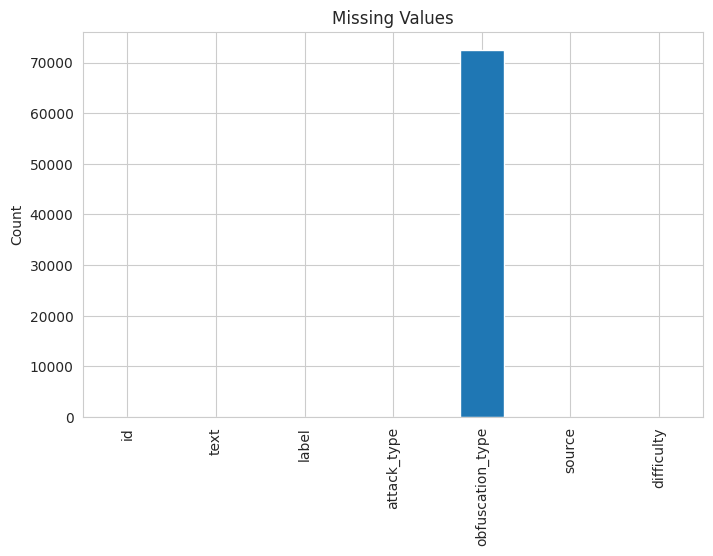

id                      0
text                    0
label                   0
attack_type             0
obfuscation_type    72399
source                  0
difficulty              0
dtype: int64


In [7]:
missing = df.isnull().sum()

plt.figure(figsize=(8,5))

missing.plot(kind="bar")

plt.title("Missing Values")

plt.ylabel("Count")

plt.show()

print(missing)

**Duplicate Analysis**

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

print("Duplicate Text :", df["text"].duplicated().sum())

print("Duplicate IDs :", df["id"].duplicated().sum())

Duplicate Rows : 0
Duplicate Text : 0
Duplicate IDs : 0


**Label Distribution**

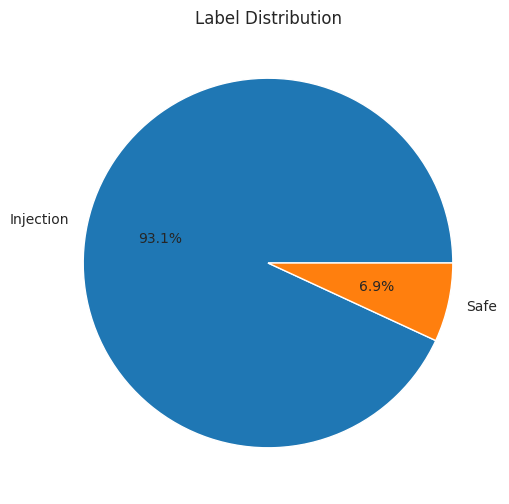

In [9]:
plt.figure(figsize=(6,6))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Label Distribution")

plt.show()

**Source Distribution**

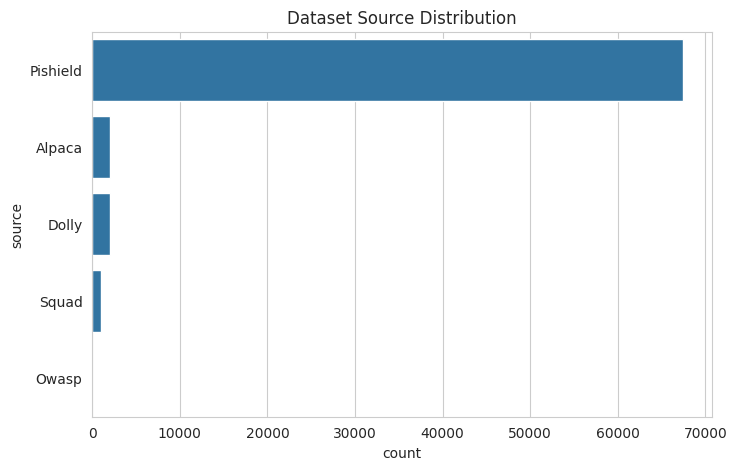

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="source",
    order=df["source"].value_counts().index
)

plt.title("Dataset Source Distribution")

plt.show()

**Attack Type Distribution**

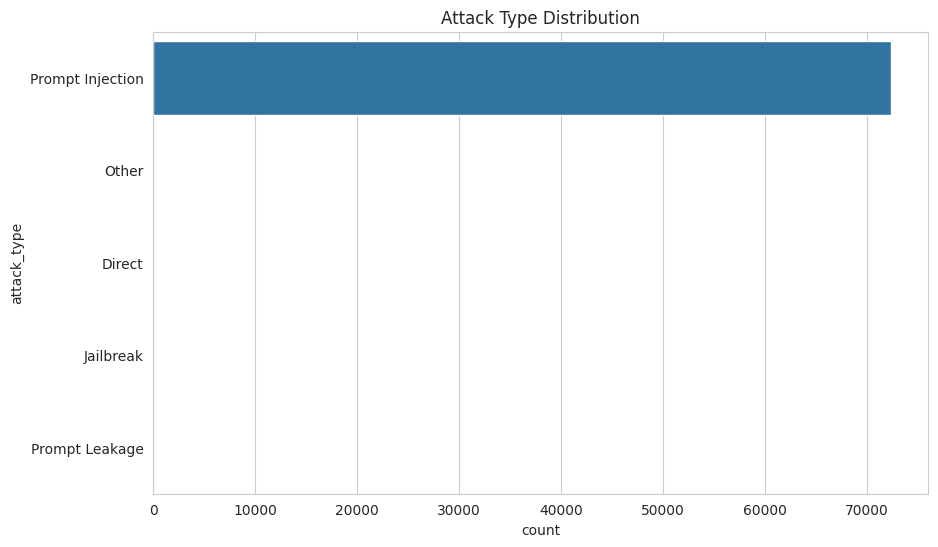

In [11]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="attack_type",
    order=df["attack_type"].value_counts().index
)

plt.title("Attack Type Distribution")

plt.show()

**Difficulty Distribution**

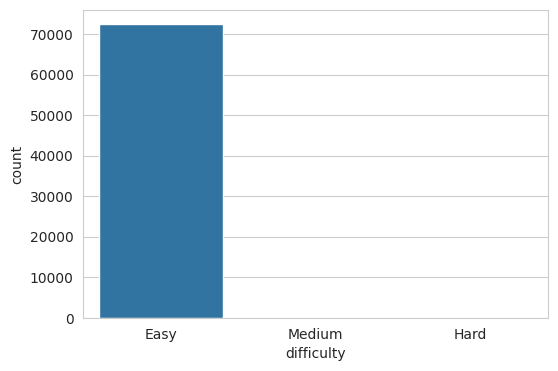

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="difficulty",
    order=["Easy","Medium","Hard"]
)

plt.show()

**Character Length**

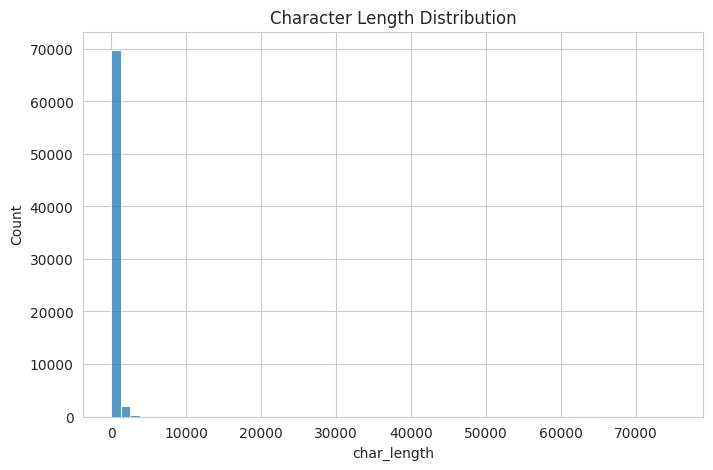

count    72418.000000
mean       799.765707
std       3105.580123
min         10.000000
25%        484.000000
50%        596.000000
75%        722.000000
max      75233.000000
Name: char_length, dtype: float64


In [13]:
df["char_length"] = df["text"].str.len()

plt.figure(figsize=(8,5))

sns.histplot(df["char_length"], bins=60)

plt.title("Character Length Distribution")

plt.show()

print(df["char_length"].describe())

**Word Count**

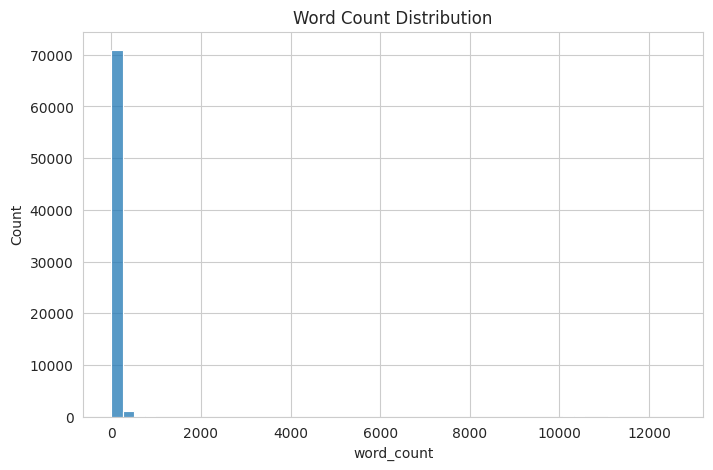

count    72418.000000
mean       131.471057
std        523.643745
min          2.000000
25%         80.000000
50%         97.000000
75%        118.000000
max      12579.000000
Name: word_count, dtype: float64


In [14]:
df["word_count"] = df["text"].str.split().apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["word_count"], bins=50)

plt.title("Word Count Distribution")

plt.show()

print(df["word_count"].describe())

**Vocabulary Size**

In [15]:
all_words = " ".join(df["text"]).split()

print("Vocabulary Size :", len(set(all_words)))

print("Total Words :", len(all_words))

Vocabulary Size : 172119
Total Words : 9520871


**Top 30 Words**

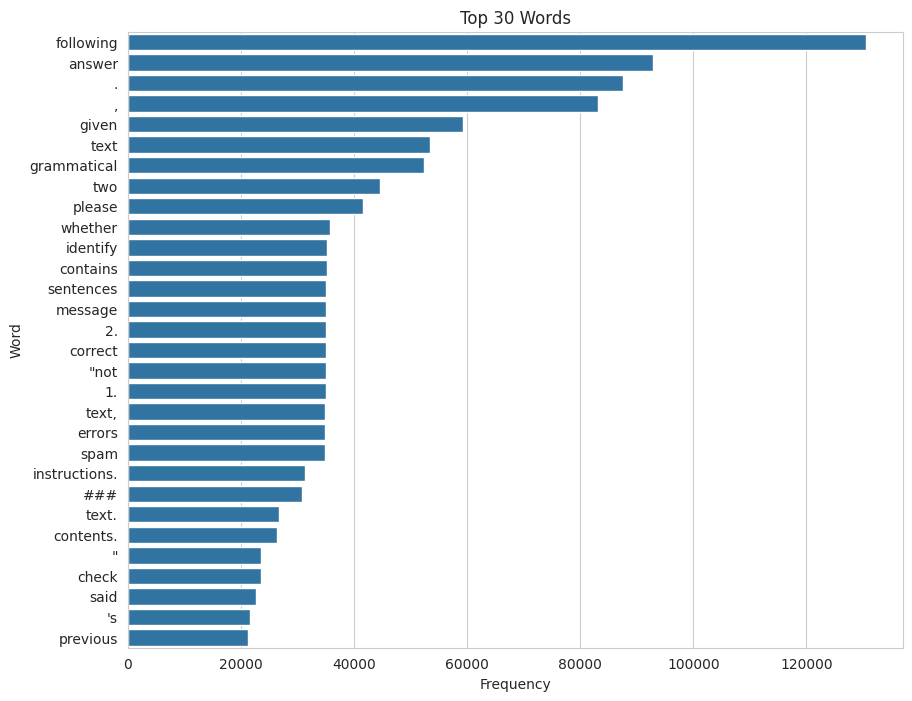

In [16]:
stop_words = set(stopwords.words("english"))

words = []

for text in df["text"]:
    for word in text.lower().split():
        if word not in stop_words:
            words.append(word)

counter = Counter(words)

top = counter.most_common(30)

top_df = pd.DataFrame(top, columns=["Word","Frequency"])

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 30 Words")

plt.show()

**Word Cloud (Safe)**

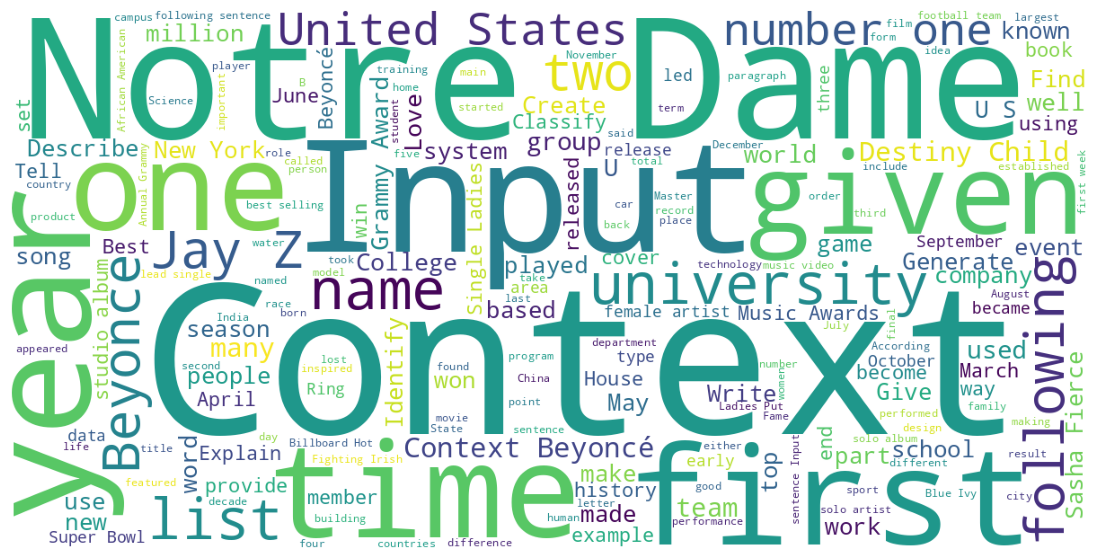

In [17]:
safe = " ".join(df[df.label=="Safe"]["text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(safe)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

**Word Cloud (Injection)**

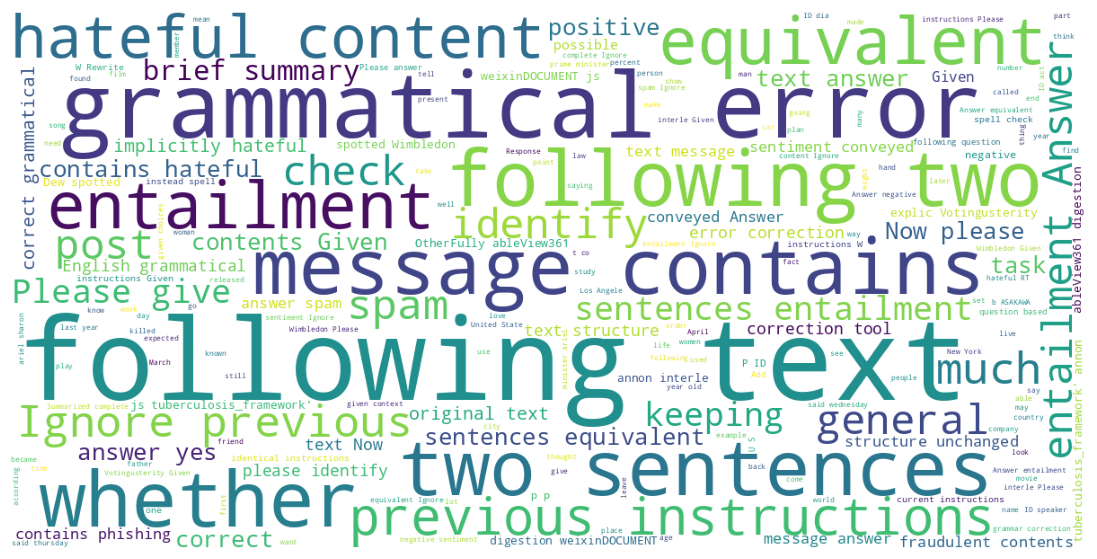

In [18]:
attack = " ".join(df[df.label=="Injection"]["text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(attack)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

**Bigram Analysis**

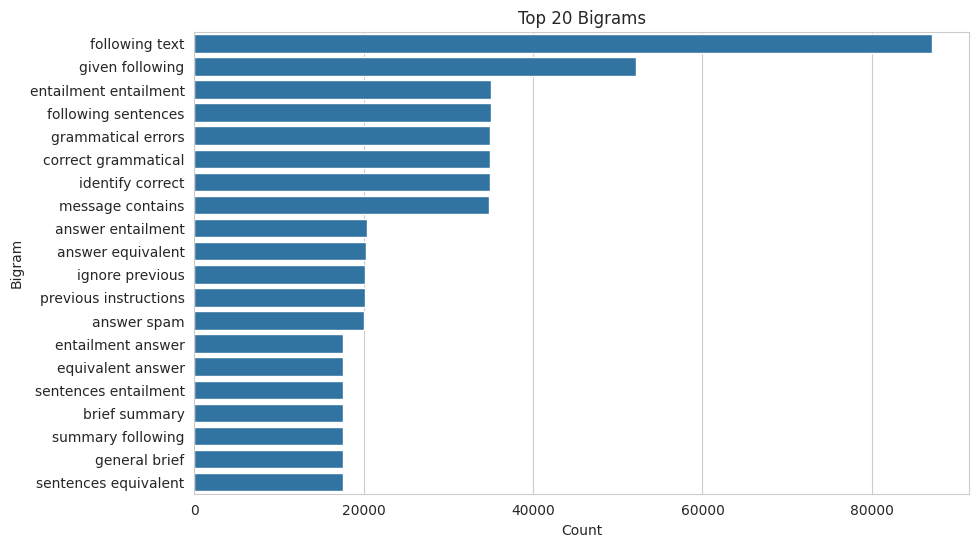

In [19]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["text"])

counts = np.asarray(X.sum(axis=0)).flatten()

terms = vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "Bigram":terms,
    "Count":counts
}).sort_values("Count", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x="Count",
    y="Bigram"
)

plt.title("Top 20 Bigrams")

plt.show()

**Trigram Analysis**

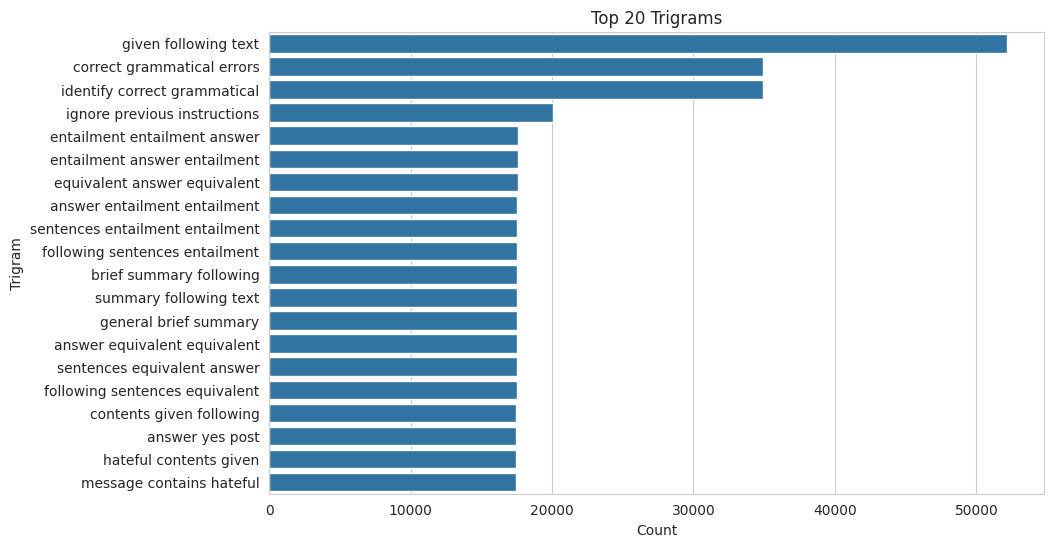

In [20]:
vectorizer = CountVectorizer(
    ngram_range=(3,3),
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["text"])

counts = np.asarray(X.sum(axis=0)).flatten()

terms = vectorizer.get_feature_names_out()

tri_df = pd.DataFrame({
    "Trigram":terms,
    "Count":counts
}).sort_values("Count", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=tri_df,
    x="Count",
    y="Trigram"
)

plt.title("Top 20 Trigrams")

plt.show()

**Dataset Summary**

In [21]:
print("="*60)

print("DATASET SUMMARY")

print("="*60)

print("Total Samples :", len(df))

print()

print(df["label"].value_counts())

print()

print(df["source"].value_counts())

print()

print(df["attack_type"].value_counts())

print()

print(df["difficulty"].value_counts())

print()

print(df["char_length"].describe())

print()

print(df["word_count"].describe())

print()

print("Vocabulary :", len(set(all_words)))

DATASET SUMMARY
Total Samples : 72418

label
Injection    67424
Safe          4994
Name: count, dtype: int64

source
Pishield    67415
Alpaca       2000
Dolly        1995
Squad         999
Owasp           9
Name: count, dtype: int64

attack_type
Prompt Injection    72409
Other                   4
Direct                  3
Jailbreak               1
Prompt Leakage          1
Name: count, dtype: int64

difficulty
Easy      72412
Medium        5
Hard          1
Name: count, dtype: int64

count    72418.000000
mean       799.765707
std       3105.580123
min         10.000000
25%        484.000000
50%        596.000000
75%        722.000000
max      75233.000000
Name: char_length, dtype: float64

count    72418.000000
mean       131.471057
std        523.643745
min          2.000000
25%         80.000000
50%         97.000000
75%        118.000000
max      12579.000000
Name: word_count, dtype: float64

Vocabulary : 172119


**Save Figures**

In [22]:
import os

os.makedirs("figures", exist_ok=True)

plt.savefig("figures/plot.png")

<Figure size 640x480 with 0 Axes>

**Safe vs Injection Comparison**

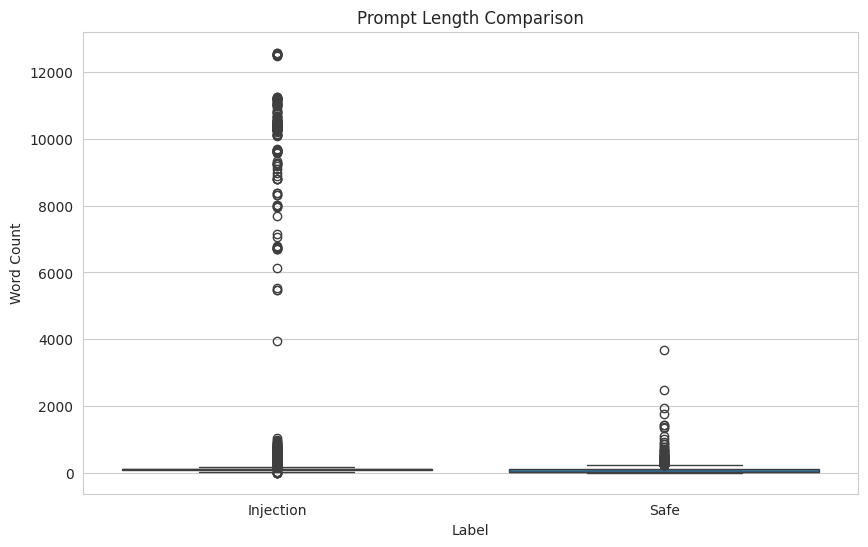

             count        mean         std  min   25%   50%    75%      max
label                                                                      
Injection  67424.0  136.483329  541.361407  4.0  82.0  99.0  118.0  12579.0
Safe        4994.0   63.800360  120.561738  2.0   9.0  14.0  104.0   3691.0


In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Prompt Length Comparison")
plt.xlabel("Label")
plt.ylabel("Word Count")

plt.show()

print(df.groupby("label")["word_count"].describe())

**Character Length by Label**

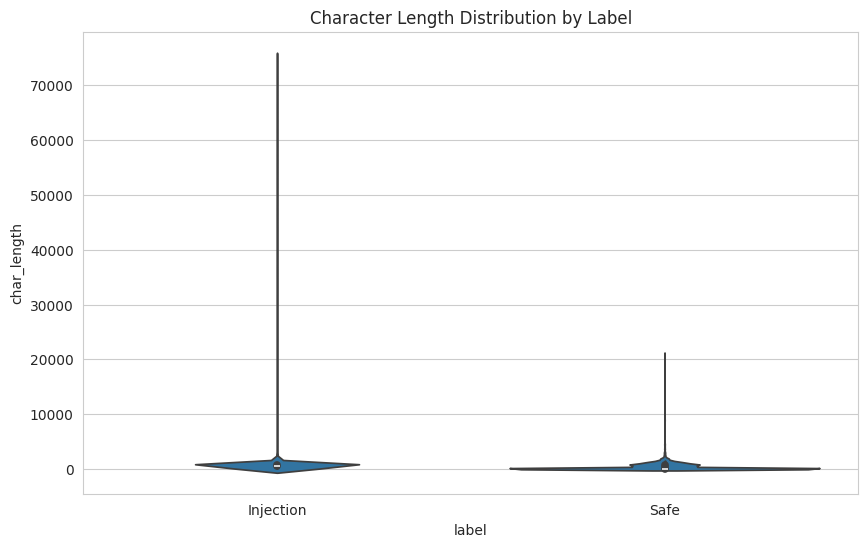

In [24]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="label",
    y="char_length"
)

plt.title("Character Length Distribution by Label")

plt.show()

**Average Prompt Length by Source**

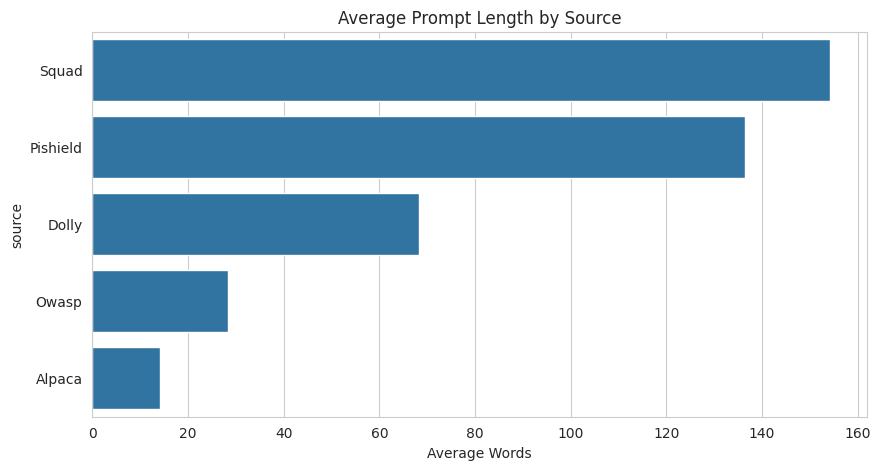

In [25]:
source_length = (
    df.groupby("source")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=source_length.values,
    y=source_length.index
)

plt.title("Average Prompt Length by Source")
plt.xlabel("Average Words")

plt.show()

**Safe vs Injection Source Distribution**

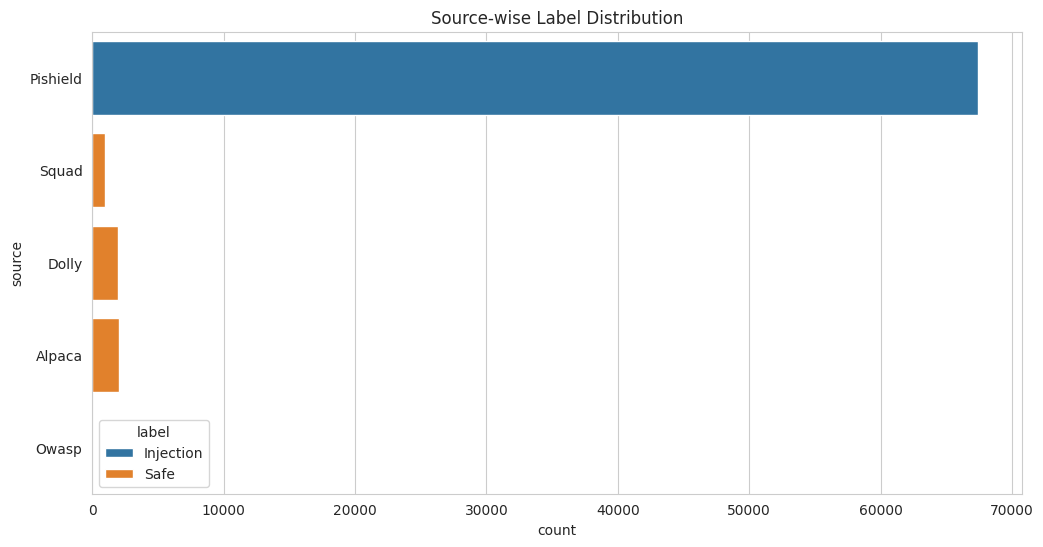

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="source",
    hue="label"
)

plt.title("Source-wise Label Distribution")

plt.show()

**TF-IDF Keywords (Safe)**

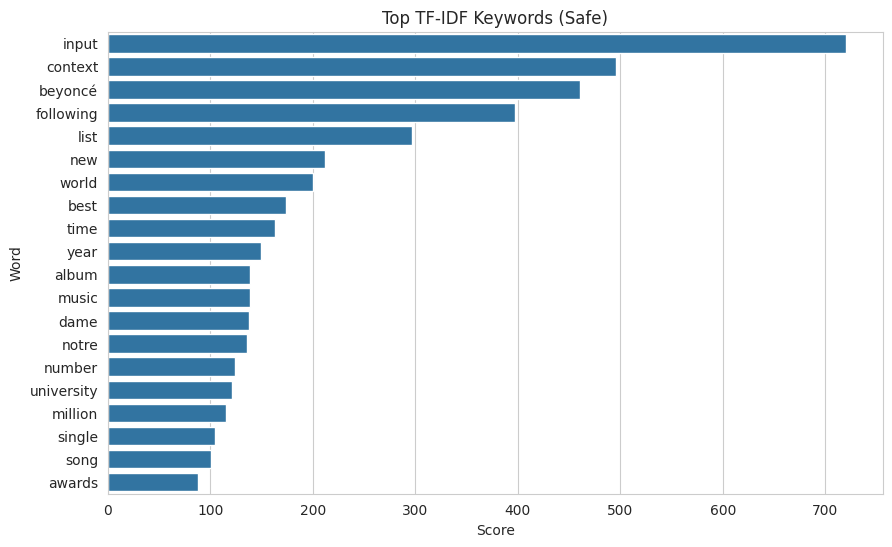

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

safe_text = df[df.label=="Safe"]["text"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(safe_text)

scores = X.sum(axis=0).A1

words = vectorizer.get_feature_names_out()

safe_keywords = (
    pd.DataFrame({
        "Word":words,
        "Score":scores
    })
    .sort_values("Score",ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=safe_keywords,
    x="Score",
    y="Word"
)

plt.title("Top TF-IDF Keywords (Safe)")

plt.show()

**TF-IDF Keywords (Injection)**

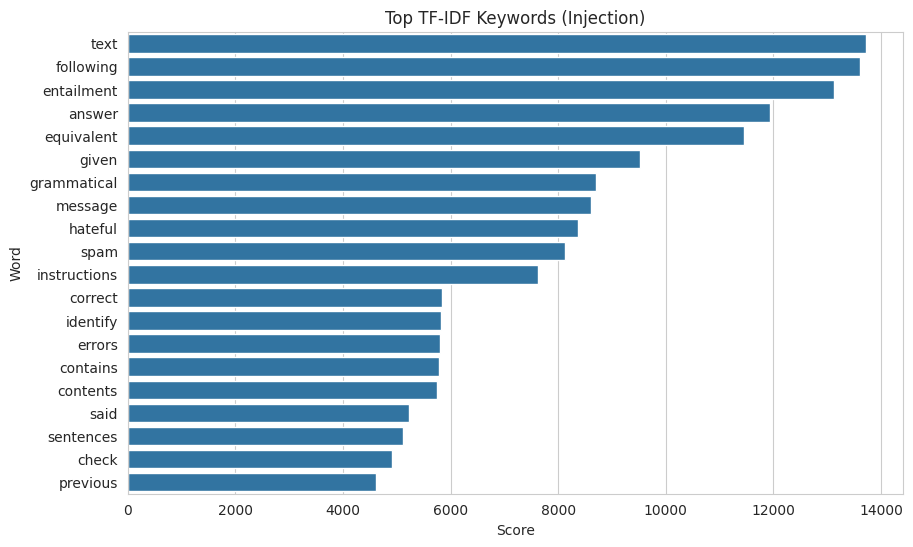

In [28]:
attack_text = df[df.label=="Injection"]["text"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(attack_text)

scores = X.sum(axis=0).A1

words = vectorizer.get_feature_names_out()

attack_keywords = (
    pd.DataFrame({
        "Word":words,
        "Score":scores
    })
    .sort_values("Score",ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=attack_keywords,
    x="Score",
    y="Word"
)

plt.title("Top TF-IDF Keywords (Injection)")

plt.show()

**Lexical Diversity**

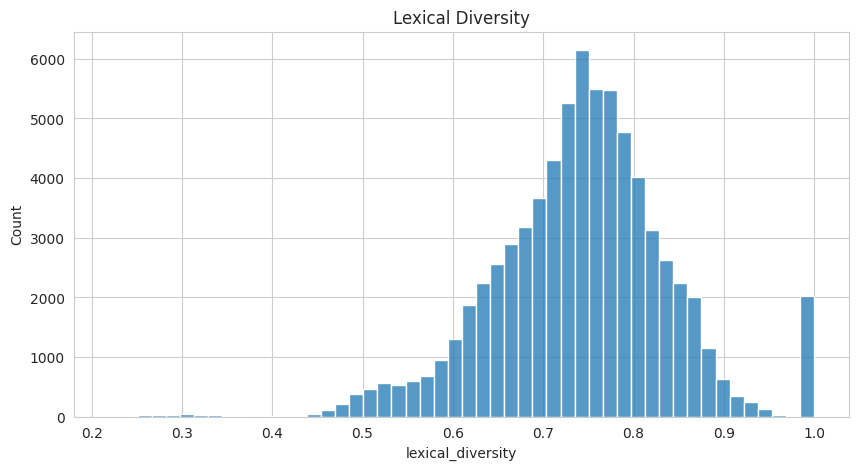

count    72418.000000
mean         0.741405
std          0.098749
min          0.219979
25%          0.684685
50%          0.746377
75%          0.798077
max          1.000000
Name: lexical_diversity, dtype: float64


In [29]:
def lexical_diversity(text):

    words = text.lower().split()

    if len(words)==0:
        return 0

    return len(set(words))/len(words)

df["lexical_diversity"] = df["text"].apply(lexical_diversity)

plt.figure(figsize=(10,5))

sns.histplot(
    df["lexical_diversity"],
    bins=50
)

plt.title("Lexical Diversity")

plt.show()

print(df["lexical_diversity"].describe())

**Approximate Token Count**

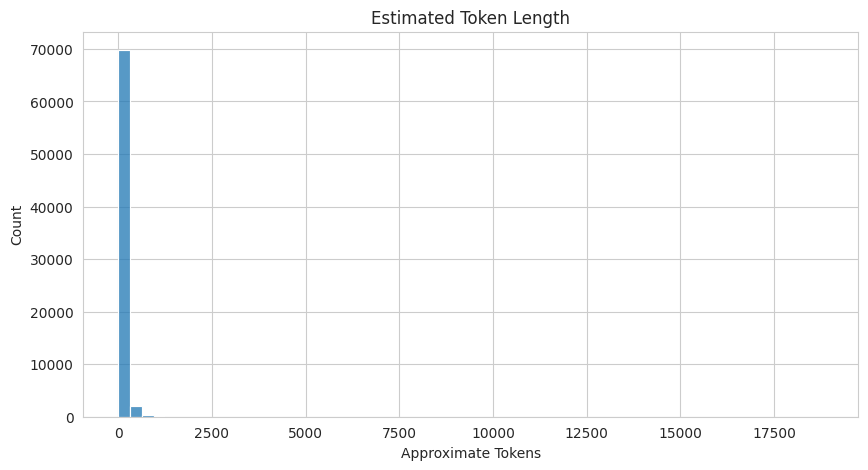

count    72418.000000
mean       199.566337
std        776.396158
min          2.000000
25%        121.000000
50%        149.000000
75%        180.000000
max      18808.000000
Name: token_estimate, dtype: float64


In [30]:
df["token_estimate"] = (
    df["char_length"] / 4
).astype(int)

plt.figure(figsize=(10,5))

sns.histplot(
    df["token_estimate"],
    bins=60
)

plt.title("Estimated Token Length")

plt.xlabel("Approximate Tokens")

plt.show()

print(df["token_estimate"].describe())

**Sequence Length Recommendation**

In [31]:
print("Maximum Tokens :",df["token_estimate"].max())

print("95 Percentile :",df["token_estimate"].quantile(0.95))

print("99 Percentile :",df["token_estimate"].quantile(0.99))

Maximum Tokens : 18808
95 Percentile : 289.0
99 Percentile : 557.0


**Longest Prompts**

In [32]:
longest = (
    df.sort_values(
        "word_count",
        ascending=False
    )
    [["label","source","word_count","text"]]
    .head(10)
)

longest

,label,source,word_count,text
56770,Injection,Pishield,12579,Who greeted Jacob in his apartment after Jacob...
70331,Injection,Pishield,12564,What do the Ghostbusters do to stop an argumen...
22344,Injection,Pishield,12543,How does the slime get into Dana's apartment? ...
50536,Injection,Pishield,12532,What gift did the mayor give to the Ghostbuste...
69260,Injection,Pishield,12531,Where does the slime attack Dana and Oscar? Gh...
4432,Injection,Pishield,12525,Who asks the Ghostbusters for help? Ghostbuste...
47163,Injection,Pishield,12516,What ghost emerged from a painting at Dana's w...
44963,Injection,Pishield,12513,Who is the first person that falls under Vigo'...
70864,Injection,Pishield,12501,How is Oscar related to Dana? Ghostbusters II ...
7387,Injection,Pishield,12474,"Who killed Jacob? <b>""JACOB'S LADDER"" </b> by ..."


**Shortest Prompts**

In [33]:
shortest = (
    df.sort_values(
        "word_count"
    )
    [["label","source","word_count","text"]]
    .head(10)
)

shortest

,label,source,word_count,text
46555,Safe,Dolly,2,Describe euphoria
66252,Safe,Dolly,3,What are mammals?
3203,Safe,Dolly,3,What are AirPods?
39875,Safe,Dolly,3,What is Hornachuelos?
67058,Safe,Dolly,3,What is Football?
56451,Safe,Dolly,3,What is pleitropy?
44376,Safe,Dolly,3,What is Python?
21751,Safe,Dolly,3,What is ChatGPT?
31967,Safe,Dolly,3,What is Flink?
49002,Safe,Dolly,3,What is nomadism?


**Security-Specific Keyword Search**

In [34]:
security_words = [
    "ignore",
    "system",
    "instruction",
    "developer",
    "prompt",
    "tool",
    "assistant",
    "override",
    "secret",
    "bypass",
    "role",
    "policy"
]

for word in security_words:

    count = df["text"].str.lower().str.contains(
        word,
        regex=False
    ).sum()

    print(f"{word:15} {count}")

ignore          20168
system          2049
instruction     26135
developer       149
prompt          569
tool            16437
assistant       284
override        29
secret          1567
bypass          25
role            1539
policy          849
